## Task 6: House Price Prediction
**Objective:**

Predict house prices using property features such as size, bedrooms, and location.

Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Upload and Load Dataset

In [4]:
df = pd.read_csv('/content/House Price Prediction Dataset.csv')

In [5]:
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


Explore Dataset

In [6]:
print(df.shape)

(2000, 10)


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


In [8]:
df.describe()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


Check missing values:

In [9]:
df.isnull().sum()

,0
Id,0
Area,0
Bedrooms,0
Bathrooms,0
Floors,0
YearBuilt,0
Location,0
Condition,0
Garage,0
Price,0


Handle Missing Values

For numerical columns:

In [10]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_1202/1384138331.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


For categorical columns:

In [11]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_1202/2422164989.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [12]:
df.isnull().sum()

,0
Id,0
Area,0
Bedrooms,0
Bathrooms,0
Floors,0
YearBuilt,0
Location,0
Condition,0
Garage,0
Price,0


Encode Categorical Features

Find categorical columns:

In [13]:
cat_cols = df.select_dtypes(include='object').columns

print(cat_cols)

Index(['Location', 'Condition', 'Garage'], dtype='object')


Encode:

In [14]:
le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

Select Features and Target

Check column names:

In [15]:
print(df.columns)


Index(['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt',
       'Location', 'Condition', 'Garage', 'Price'],
      dtype='object')


Assume target column is Price.

In [16]:
X = df.drop('Price', axis=1)
y = df['Price']

Feature Scaling

In [17]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

Split Dataset

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

Train Linear Regression Model

In [19]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

Make Predictions

In [20]:
y_pred = model.predict(X_test)

View predictions:

In [21]:
results = pd.DataFrame({
    'Actual Price': y_test,
    'Predicted Price': y_pred
})

results.head()

,Actual Price,Predicted Price
1860,514764,499892.687702
353,694256,547716.211468
1333,66375,497957.441446
905,650243,561541.780393
1289,223285,569998.440012


Evaluate Model

MAE

In [22]:
mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 244003.46389812752


RMSE

In [23]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Root Mean Squared Error:", rmse)

Root Mean Squared Error: 280469.73802789196


R² Score

In [24]:
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: -0.011111291082151142


Actual vs Predicted Visualization

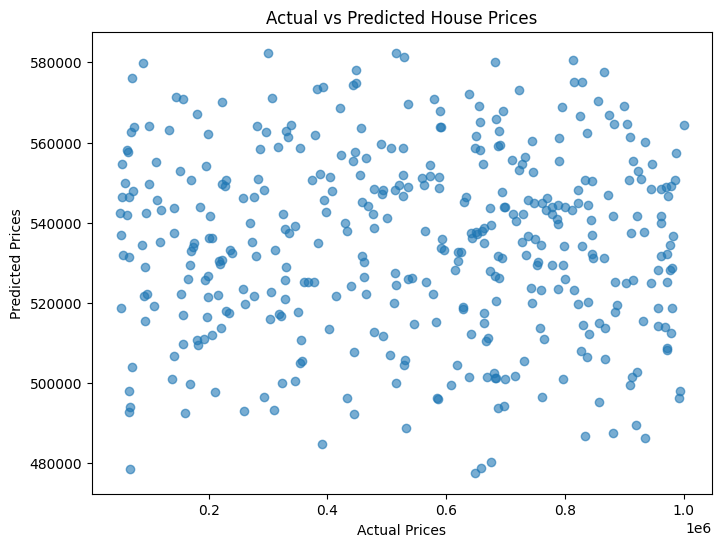

In [25]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")

plt.show()

Regression Line Plot

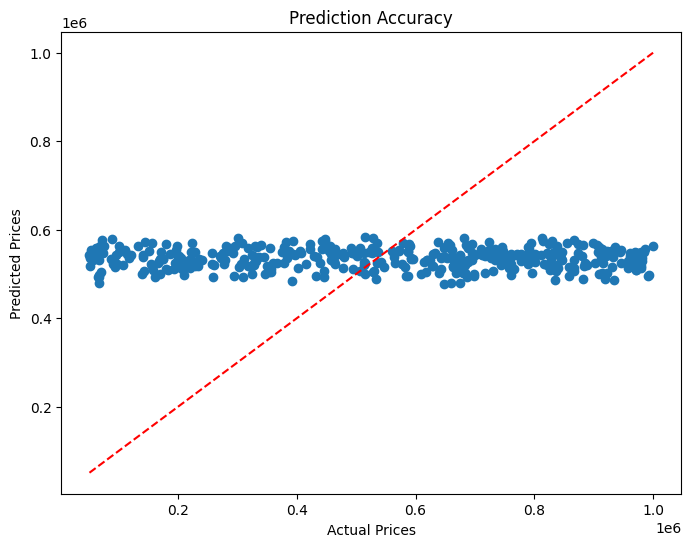

In [26]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Prediction Accuracy")

plt.show()

Feature Importance (Coefficients)

In [27]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

coefficients.sort_values(
    by='Coefficient',
    ascending=False
)

,Feature,Coefficient
4,Floors,19029.835492
5,YearBuilt,4011.971815
8,Garage,1850.922103
2,Bedrooms,155.399751
1,Area,-379.040917
7,Condition,-2797.120874
6,Location,-2987.699016
0,Id,-7054.499916
3,Bathrooms,-11217.714034


Predict Price for New House

In [33]:
sample_house = pd.DataFrame(
    [[1001, 2500, 4, 3, 2, 2018, 1, 1, 1]],
    columns=X.columns
)

Scale the Features

In [34]:
sample_scaled = scaler.transform(sample_house)

Predict the Price

In [35]:
predicted_price = model.predict(sample_scaled)

print("Predicted House Price:", predicted_price[0])

Predicted House Price: 542333.239024842


In [30]:
sample_house = X.iloc[[0]]

sample_scaled = scaler.transform(sample_house)

prediction = model.predict(sample_scaled)

print("Predicted Price:", prediction[0])
print("Actual Price:", y.iloc[0])

Predicted Price: 564448.641174576
Actual Price: 149919
